Goal: Create a hierarchical clustering built upon both genotypic and phenotypic information. 

One proposal (40 total features): 
- 20 features for normalized abundance at T0 across native pHs
- 11 features for normalized abundance at T9 across perturbed pHs
- 9 features for structural and sequence-based information:
  - (3) Alpha helix, Beta sheet, Coil proportions
  - (2) Solvent-Accessible surface area (both total and average per residue)
  - (1) Radius of Gyration (compactness)
  - (1) Length
  - (1) Instability Index
  - (1) Isoelectric Point (pI) — pH at which the protein is net neutral




First, I need the ORFs for each of the 60 for which we have a compelete sequence after the first clustering. Then, I will use a cluster map to reduce redudancy, gather the relevant data for each one. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mgsa.helpers import plot
from mgsa.io import get_data
 
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


Start over, no conditioning out, but using the incomplete to complete map

In [2]:
KO = 'K00370'
map = '09'
Drug = 'None'

complete_ids = pd.read_csv(f'../out/aaseqs/{KO}/long_complete_orf_ids.txt', header = None)
complete_ids = complete_ids.values
print(complete_ids.shape, complete_ids.dtype)

all_ids = pd.read_csv(f'../out/orf_ids/cluster_ids_{map}_{KO}.tsv', sep = '\t', header=None)

map = pd.read_csv(f'../out/aaseqs/{KO}/incomplete_to_complete_seq_mapping.tsv', sep = '\t')
map = map.values
print(map[:,1].shape, map[:,1].dtype)
print(map)

T0data = np.zeros((len(complete_ids), 20))
T9data = np.zeros((len(complete_ids), 10, 11))

for i, id in enumerate(complete_ids):
    got_data = get_data(id, drug = Drug, KO=KO)
    T0data[i] += got_data[0]
    T9data[i] += got_data[1]

print(T9data[:,:,1].shape)

for i, id in enumerate(map[:,0]):
    complete_id = map[i, 1]
    idx = np.where(complete_ids == complete_id)[0][0]
    got_data = get_data(id, drug = Drug)
    T0data[idx] += got_data[0]
    T9data[idx] += got_data[1]






(57, 1) object
(451,) object
[['Soil11.scaffold_669406189_c1_1' 'Soil9.scaffold_209032411_c1_3'
  5.449392712550607]
 ['Soil11.scaffold_168782194_c1_1' 'Soil9.scaffold_209032411_c1_3'
  4.704142011834319]
 ['Soil11.scaffold_603781636_c1_1' 'Soil15.scaffold_116822102_c1_19'
  4.966360856269113]
 ...
 ['T0.scaffold_685359621_c1_1' 'Soil6.scaffold_312871021_c1_4'
  4.787878787878788]
 ['T0.scaffold_925671294_c1_1' 'Soil17.scaffold_274056314_c1_61'
  4.8262108262108265]
 ['T0.scaffold_409096425_c1_1' 'Soil5.scaffold_183283646_c1_24'
  5.014767932489452]]
(57, 10)


In [3]:
# Script to count occurrences of target names and sort alphabetically

# Read the file and count occurrences
target_counts = {}
KO = 'K00370'

with open(f'../out/aaseqs/{KO}/incomplete_to_complete_seq_mapping.tsv', 'r') as file:
    # Skip header line
    next(file)
    
    for line in file:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            target_name = parts[1]
            target_counts[target_name] = target_counts.get(target_name, 0) + 1

# Sort target names alphabetically
sorted_targets = sorted(target_counts.items())

# Write results to a new file
with open('target_counts.txt', 'w') as output_file:
    output_file.write("target_name\tcount\n")
    for target_name, count in sorted_targets:
        output_file.write(f"{target_name}\t{count}\n")

# Print summary
print(f"Total distinct target names: {len(sorted_targets)}")
print("Results written to 'target_counts.txt'")

Total distinct target names: 51
Results written to 'target_counts.txt'


[[6505. 2888. 2987. ... 2950. 5906. 2973.]
 [2888. 6662. 3282. ... 4721. 2914. 3331.]
 [2987. 3282. 6539. ... 3258. 3002. 4512.]
 ...
 [2950. 4721. 3258. ... 6743. 2975. 3230.]
 [5906. 2914. 3002. ... 2975. 6519. 3032.]
 [2973. 3331. 4512. ... 3230. 3032. 6674.]]


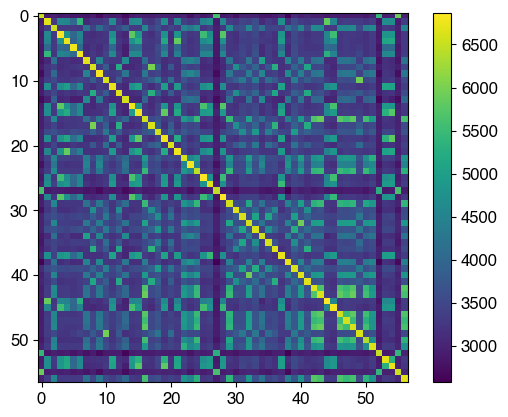

In [22]:

from sklearn.preprocessing import MinMaxScaler, StandardScaler

strc_data = pd.read_csv(f'../out/structure_analysis/{KO}/structure_metrics_{KO}.tsv', sep='\t')
strc_data = strc_data.values
strc_data = strc_data[:, 1:]#remove the first column (orf names)

scaler = MinMaxScaler()
strc_data = scaler.fit_transform(strc_data)


data_abs = T0data
T0data = T0data / T0data.sum(axis = 1, keepdims=True)
T0data = np.nan_to_num(T0data, nan = 0)

data = T0data 
for i in range(10):
    T9temp = T9data[:,i,:]
    data_abs = np.hstack((data_abs, T9temp))
    T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)
    T9temp = np.nan_to_num(T9temp, nan = 0)
    data = np.hstack((data, T9temp))
    

pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')

data_abundances = data #saving for later
data_sequences = pairwise_data #saving for later

print(pairwise_data)
plt.imshow(pairwise_data)
plt.colorbar()
pairwise_data = scaler.fit_transform(pairwise_data)
np.savetxt(f"../out/K00370abundances/complete_abundances_nrm.tsv", data, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/K00370abundances/complete_abundances_abs.tsv", data_abs, delimiter = '\t', fmt = '%0.6f')



data = np.hstack((data, pairwise_data))
data_abs = np.hstack((data_abs, pairwise_data))
#data = np.hstack((data, strc_data))




# weights = np.concatenate([
#     np.full(20, 1/np.sqrt(20)),    
#     np.full(110, 1/np.sqrt(110)) ,
#     np.full(57, 1/np.sqrt(57))
# ])

a = 0.5
weights = np.concatenate([
    np.full(20, a**2/np.sqrt(130)),    
    np.full(110, a**2/np.sqrt(130)) ,
    np.full(57, (np.sqrt(1 - a**2))/np.sqrt(57))
])


# weights = np.concatenate([
#     np.full(20, 1/np.sqrt(20)),    
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(10, 0),  
#     np.full(1, 1/np.sqrt(11)),
#     np.full(57, 1/np.sqrt(57)),    
# ])


weighted_data = data * weights 



[28, 14, 3, 45, 25, 26, 37, 53, 11, 19, 15, 54, 4, 21, 6, 1, 44, 5, 52, 0, 27, 55, 10, 49, 20, 35, 31, 33, 39, 18, 30, 8, 17, 41, 36, 12, 13, 7, 34, 23, 38, 9, 2, 22, 51, 40, 32, 29, 24, 47, 42, 56, 50, 46, 43, 16, 48]


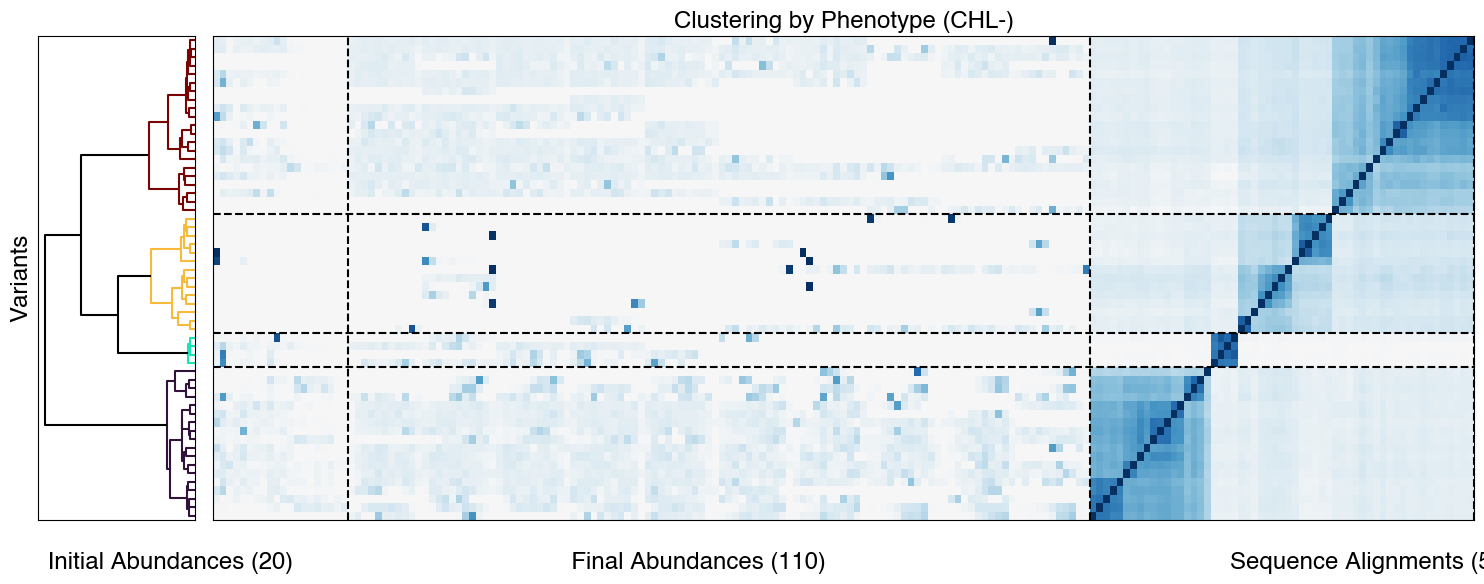

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex


Z = linkage(weighted_data, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

n_clusters = 4
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
    

#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [0.5, 4]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(data)

rearranged_data = data[leaf_indices]
col_leaf_indices = leaf_indices+130*np.ones(57, dtype = int)
rearranged_data[:, 130:187] = rearranged_data[:, col_leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin = -1, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
for b in boundaries:
    ax2.axhline(b + 0.5, color='black', linestyle='--')
    
ax2.axvline(19.5, color='black', linestyle='--')
ax2.axvline(129.5, color='black', linestyle='--')
ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_title('Clustering by Phenotype (CHL-)', fontname='Helvetica', fontsize = 'x-large')
ax2.set_xlabel('\n Initial Abundances (20) \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t        Final Abundances (110)   \t \t \t \t \t  \t \t \t \t  \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t Sequence Alignments (57) \t \t \t \t \t \t \t \t \t \t', fontname='Helvetica', fontsize = 'x-large')

#ax2.set_ylabel('Variants', fontname='Helvetica', fontsize='x-large')

ax2.set_yticks([])
ax2.set_yticks([])
plt.tight_layout()

print(leaf_indices)
    
plt.show()

### compute within group and out of group mean alignment scores. 

[[ 78405.29411765 130361.29411765]
 [  8162.         119624.25      ]
 [ 47307.         138824.35714286]
 [ 90057.63636364 114169.59090909]]
1.6626593342286327
14.656242342563097
2.934541550782277
1.267739144830482
within/out: 0.4452108564413951
out/within: 2.2461267184566824


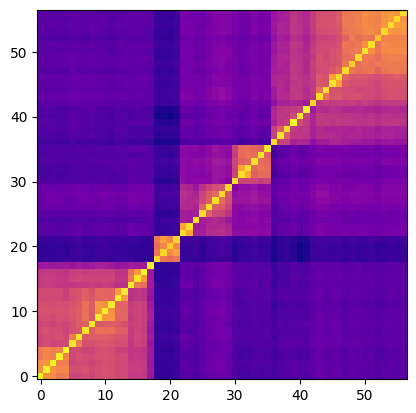

In [6]:
new_data = data_abs[leaf_indices]
pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')
pairwise_data = pairwise_data[leaf_indices] #rearrange rows
pairwise_data = pairwise_data[:, leaf_indices] #rearrange columns
plt.imshow(pairwise_data, origin = 'lower', cmap = 'plasma')

alignment = np.zeros((n_clusters, 2))
#alignment[0]: within group sum
#alignment[1]: out of group sum

membership = np.zeros(n_clusters) #size of each group in an array
for i in range(n_clusters):
    if i == 0:
        membership[i] = boundaries[0]
    elif i < n_clusters - 1:
        membership[i] = boundaries[i] - boundaries[i - 1]
    elif i == n_clusters - 1:
        membership[i] = 57 - boundaries[i - 1]

for i in range(57):
    for j in range(1, n_clusters-1):
        if i > boundaries[j - 1] and i < boundaries[j]: #if in j^th group
            for k in range(57):
                if k > boundaries[j - 1] and k < boundaries[j] and k != i:
                    alignment[j, 0] += pairwise_data[i, k]/membership[j]
                elif k != i:
                    alignment[j, 1] += pairwise_data[i, k]/membership[j]
    if i < boundaries[0]: #if in first group
        for k in range(57):
            if k < boundaries[0] and k != i:
                alignment[0, 0] += pairwise_data[i, k]/membership[0]
            elif k != i:
                alignment[0, 1] += pairwise_data[i, k]/membership[0]
    elif i > boundaries[n_clusters-2]: #if in last group
        for k in range(57):
            if k > boundaries[n_clusters-2] and k != i:
                alignment[n_clusters - 1, 0] += pairwise_data[i, k]/membership[n_clusters - 1]
            elif k != i:
                alignment[n_clusters - 1, 1] += pairwise_data[i, k]/membership[n_clusters - 1]

print(alignment)
within = 0
out = 0
for i in range(n_clusters):
    within += alignment[i, 0]
    out += alignment[i, 1]
    print(alignment[i, 1]/alignment[i, 0])
    
print('within/out:', within/out)
print('out/within:', out/within)

(57, 187)
(57, 187)
[17 21 35]


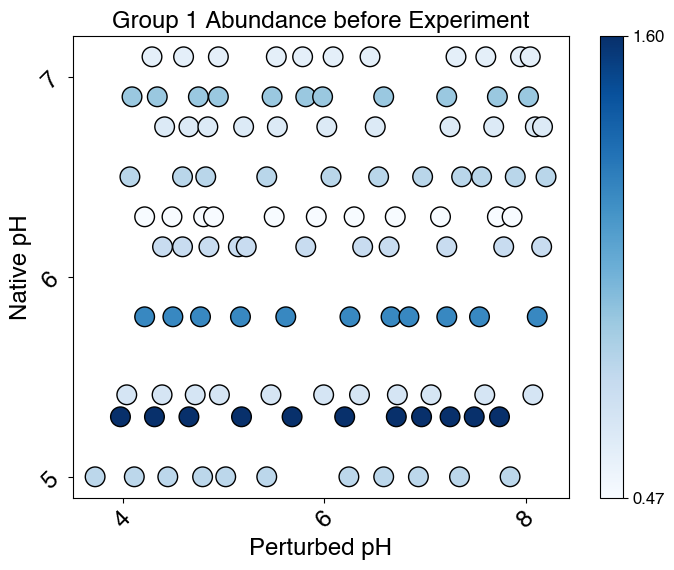

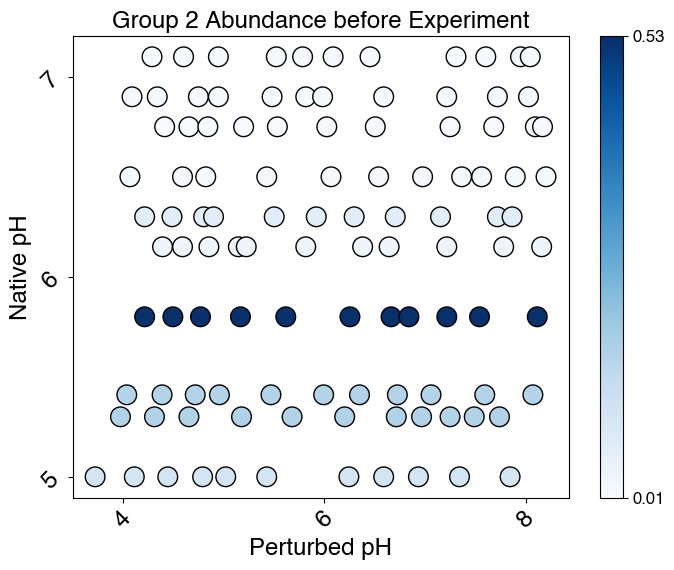

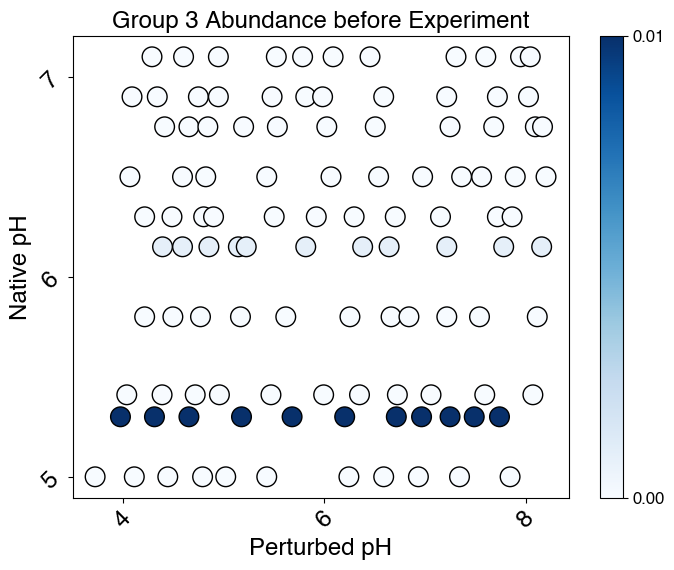

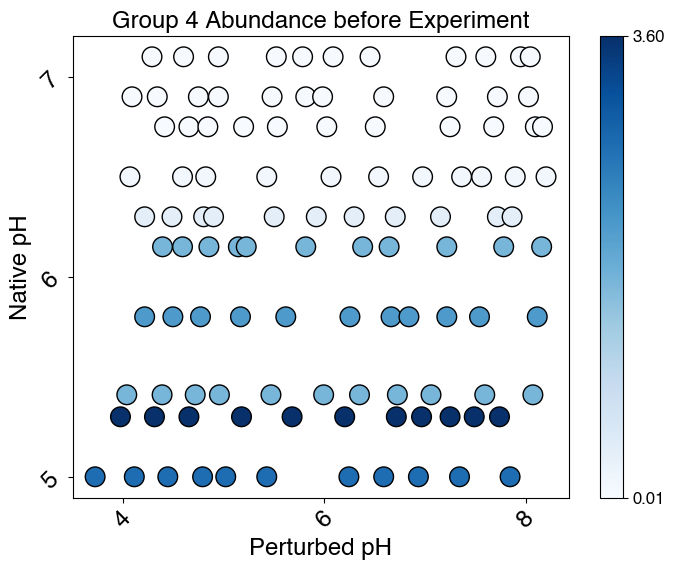

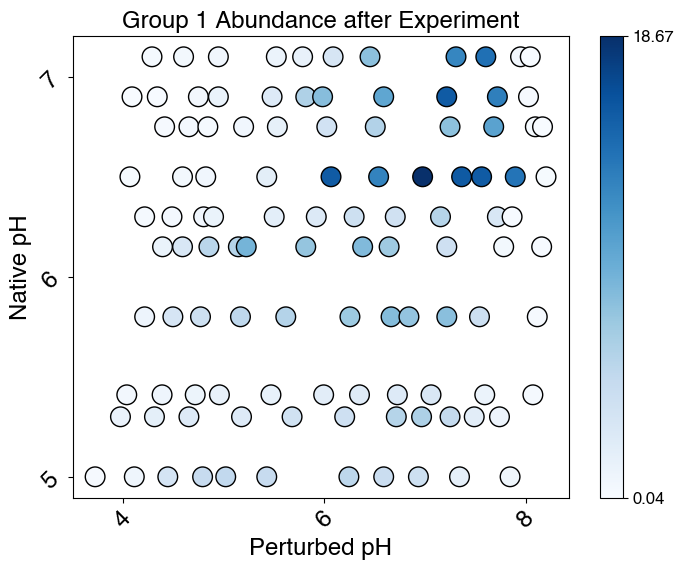

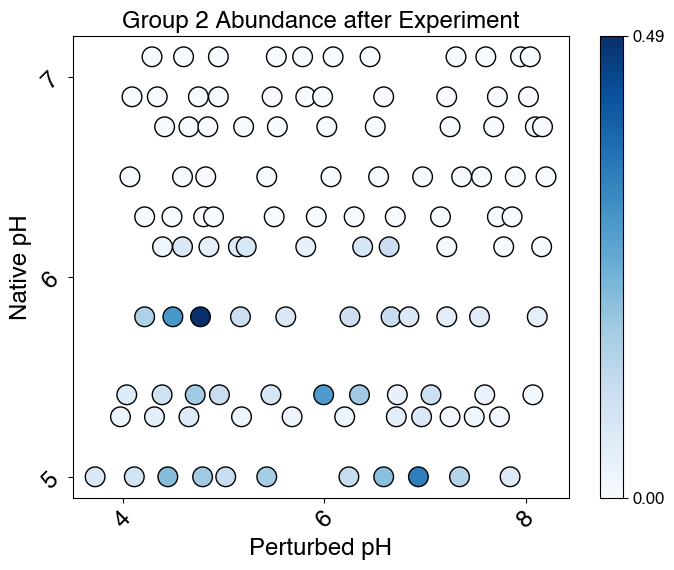

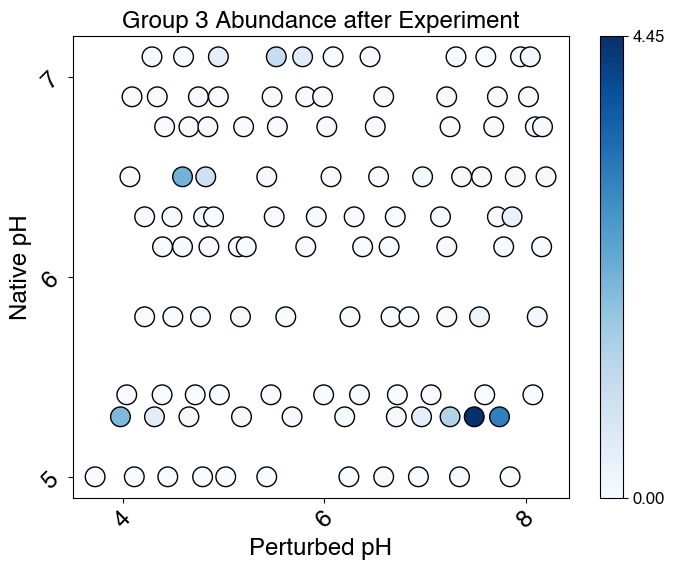

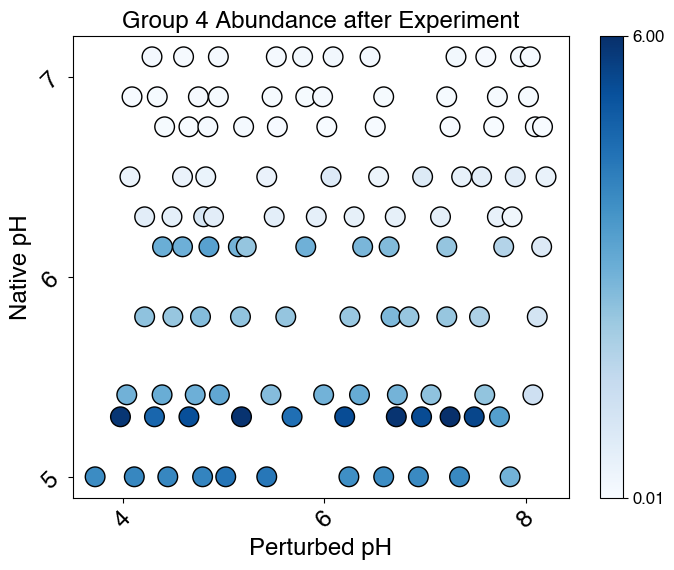

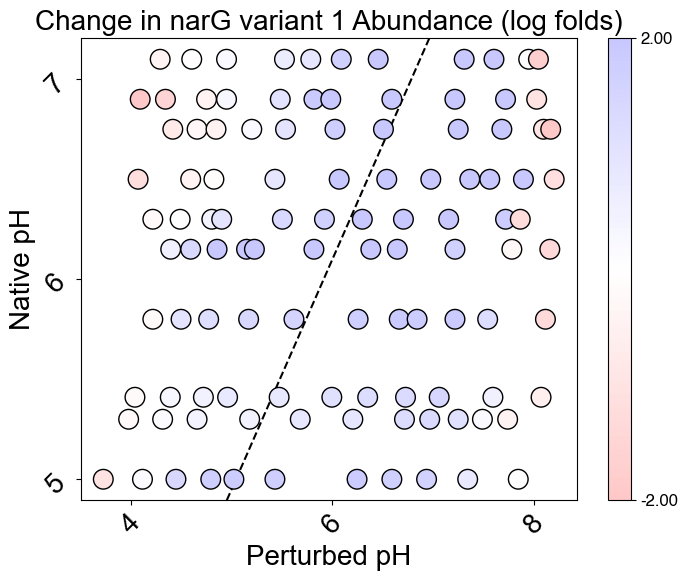

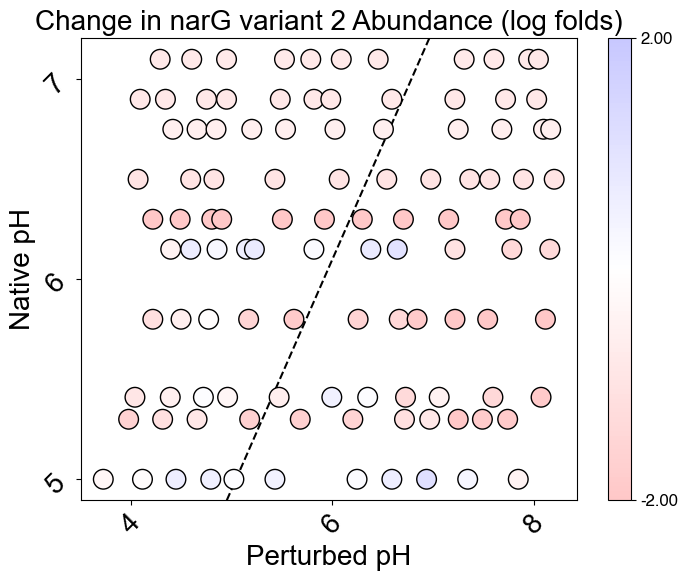

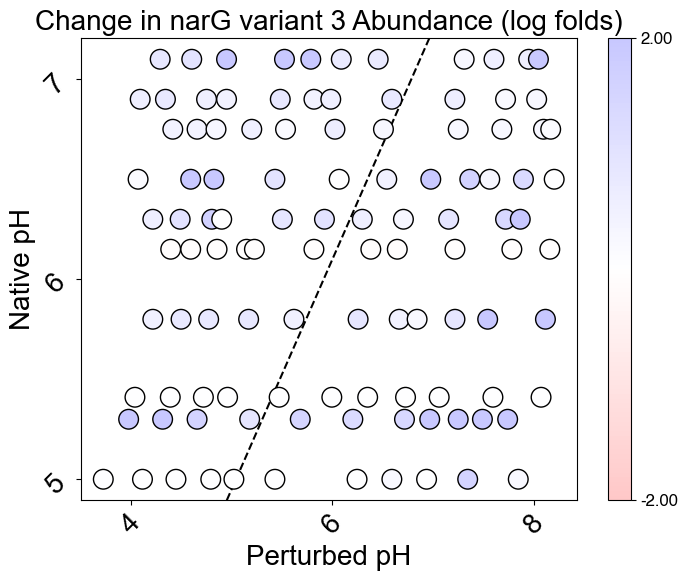

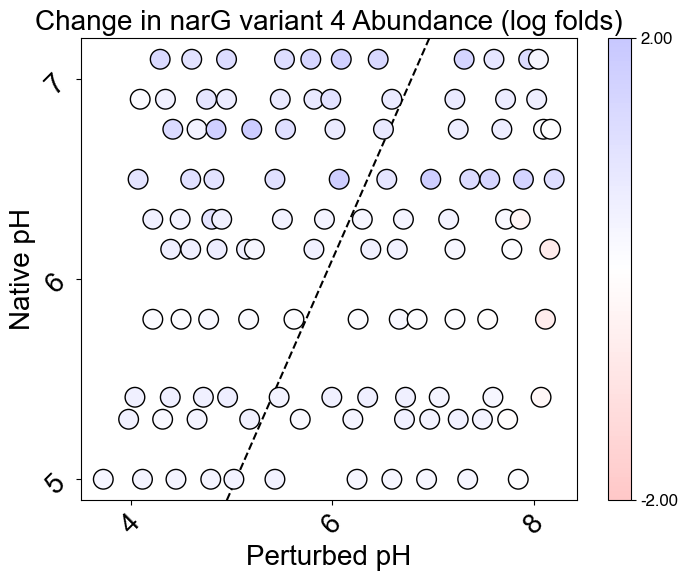

In [103]:


print(data.shape)
print(new_data.shape)
print(boundaries)
from mgsa.helpers import plot

groups = np.zeros((n_clusters,187))

for i, datum in enumerate(new_data):
    for j in range(1, n_clusters-1):
        if i > boundaries[j - 1] and i < boundaries[j]:
            groups[j] += datum
    if i < boundaries[0]:
        groups[0] += datum
    elif i > boundaries[n_clusters-2]:
        groups[n_clusters-1] += datum




selected = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]

#T0
groups_T0 = [np.zeros((10, 11)) for _ in range(n_clusters)]

for i in range(10): #native pH
    for j in range(n_clusters):
        groups_T0[j][i] = groups[j][selected][i]
        
for j in range(n_clusters):
    plot(groups_T0[j], f'Group {j+1} Abundance before Experiment')

#T9
groups_T9 = [np.zeros((10, 11)) for _ in range(n_clusters)]

for i in range(10): #native pH
    for j in range(11): #perturbed pH
        for k in range(n_clusters):
            groups_T9[k][i][j] = groups[k][20 + 11*i + j]
            
for i in range(n_clusters):
    plot(groups_T9[i],  f'Group {i+1} Abundance after Experiment')
    
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define your RGB colors
negative_color = (255/255, 200/255, 200/255)  # Light red
positive_color = (200/255, 200/255, 255/255)  # Light blue

# Create a colormap that goes from negative_color to white to positive_color
# For a diverging colormap with center at 0
colors = [negative_color, (1, 1, 1), positive_color]  # White in the middle
n_bins = 100  # Number of discrete colors in the colormap

# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_diverging', colors, N=n_bins
)
        
for i in range(n_clusters):
    plot(np.log((groups_T9[i] + 0.01*np.ones_like(groups_T9[i])) /  (groups_T0[i]+ 0.01 * np.ones_like(groups_T0[i]))), f'Change in narG variant {i+1} Abundance (log folds)', vmin = -2, vmax = 2, include_line = True, fontname = 'Arial', fontsize = 20, cmap = custom_cmap)
    #plot(groups_T9[i] - groups_T0[i], 'change subtraction', cmap = 'RdBu', vmin = -1, vmax = 1)

#change



In [8]:
orf_list = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header=None)
orf_list = orf_list.values
orf_list = [orf[0] for orf in orf_list]

# Simple pairing of ORFs with their cluster assignments
v1_clusters_simple = list(zip(orf_list, clusters))

with open("../out/groups/assignments_K00370_v2.tsv", 'w') as f:
    for orf, cluster in v1_clusters_simple:
        f.write(f"{orf} {cluster}\n")

# Reorder according to dendrogram
v1_clusters_reordered = [v1_clusters_simple[i] for i in leaf_indices]

for orf, cluster in v1_clusters_reordered:
    print(f"{orf}: Cluster {cluster}")
    

Soil5.scaffold_215117222_c1_59: Cluster 1
Soil16.scaffold_804923086_c1_3: Cluster 1
Soil11.scaffold_211583530_c1_6: Cluster 1
Soil6.scaffold_460055642_c1_2: Cluster 1
Soil3.scaffold_408070428_c1_2: Cluster 1
Soil3.scaffold_285743490_c1_2: Cluster 1
Soil5.scaffold_416434691_c1_48: Cluster 1
T0.scaffold_786865677_c1_2: Cluster 1
Soil15.scaffold_16321085_c1_6: Cluster 1
Soil17.scaffold_1202428475_c1_2: Cluster 1
Soil16.scaffold_313969256_c1_10: Cluster 1
T0.scaffold_172278247_c1_4: Cluster 1
Soil12.scaffold_266712765_c1_2: Cluster 1
Soil17.scaffold_332687915_c1_2: Cluster 1
Soil14.scaffold_280216268_c1_12: Cluster 1
Soil11.scaffold_587233302_c1_1: Cluster 1
Soil6.scaffold_312871021_c1_4: Cluster 1
Soil14.scaffold_576820813_c1_40: Cluster 1
Soil9.scaffold_711597457_c1_4: Cluster 2
Soil11.scaffold_431547323_c1_2: Cluster 2
Soil5.scaffold_133269568_c1_66: Cluster 2
T0.scaffold_961428012_c1_71: Cluster 2
Soil15.scaffold_175810641_c1_3: Cluster 3
Soil9.scaffold_816779774_c1_14: Cluster 3
Soil1

### PCA to show genotype and phenotype vary together

(57, 130)
(57, 57)
Explained variance ratio (genotype): [0.50918757 0.21565601 0.10417923]
Explained variance ratio (phenotype): [0.17686659 0.0995724  0.0723671 ]
Total explained variance (genotype): 82.9%
Total explained variance (phenotype): 34.9%


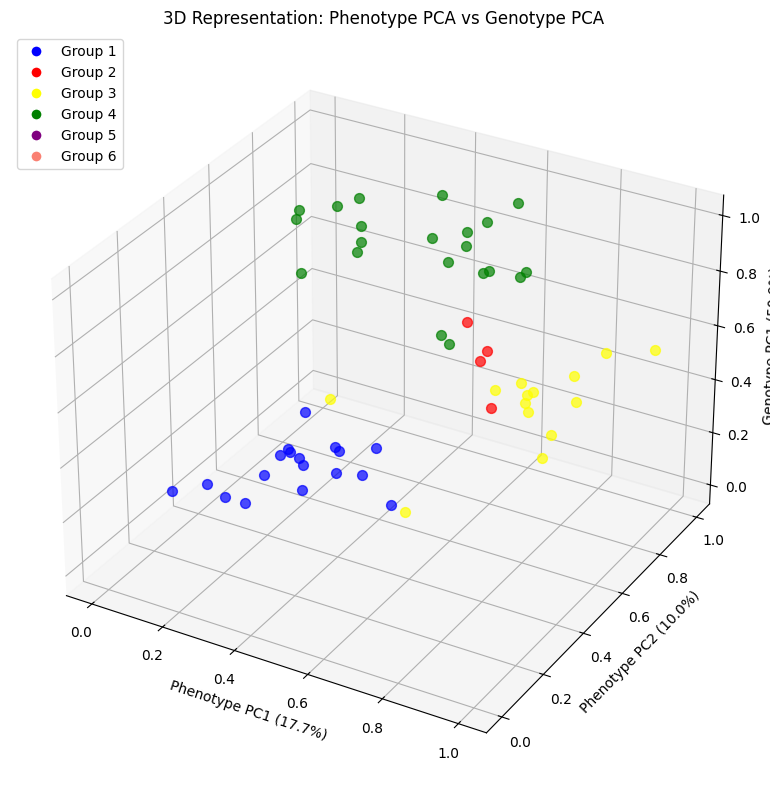

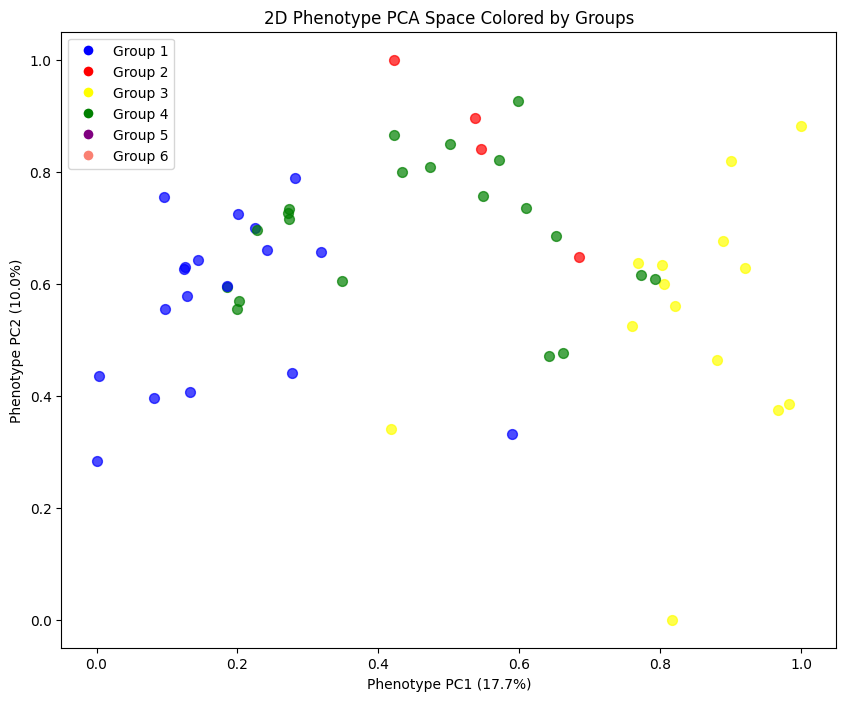

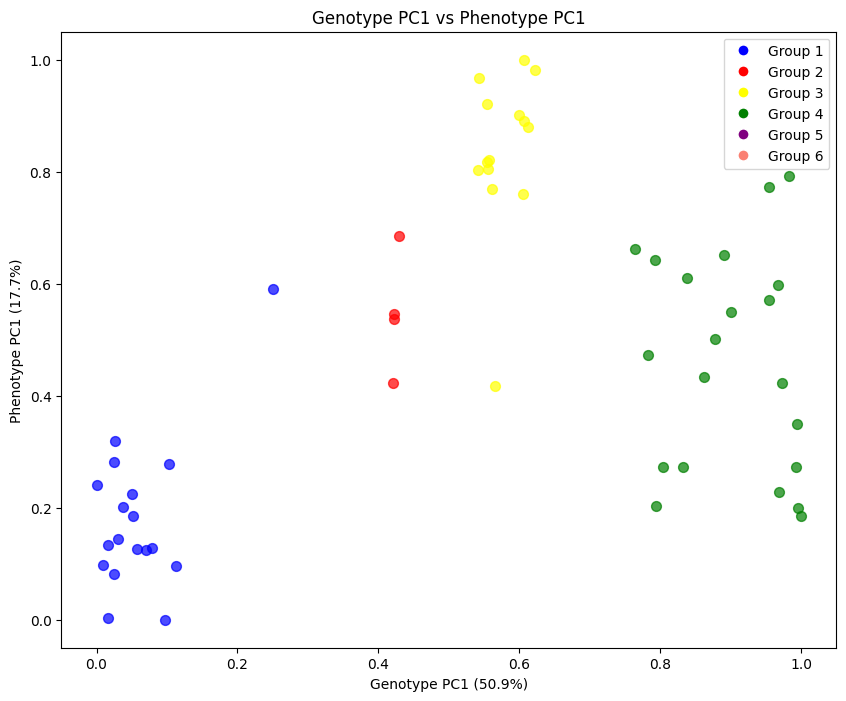

In [9]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

KO = 'K00370'
genotype_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')
phenotype_data = pd.read_csv(f'../out/{KO}abundances/complete_abundances_nrm', sep = '\t', header = None)

print(phenotype_data.shape)
print(genotype_data.shape)

# Step 1: Center the data 
phenotype_data = phenotype_data - np.mean(phenotype_data, axis=0)
genotype_data = genotype_data - np.mean(genotype_data, axis=0)

# Step 2: Apply PCA to both genotype and phenotype data
pca_g = PCA(n_components=3)  
pca_p = PCA(n_components=3)  

g_pca = pca_g.fit_transform(genotype_data)
p_pca = pca_p.fit_transform(phenotype_data)

# Step 3: Inspect results
print("Explained variance ratio (genotype):", pca_g.explained_variance_ratio_)
print("Explained variance ratio (phenotype):", pca_p.explained_variance_ratio_)
print("Total explained variance (genotype): {:.1f}%".format(pca_g.explained_variance_ratio_.sum() * 100))
print("Total explained variance (phenotype): {:.1f}%".format(pca_p.explained_variance_ratio_.sum() * 100))

# clusters 
assignments = pd.read_csv("../out/groups/assignments_K00370_v2.tsv", sep = '\t', header = None).values

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Normalize the first two components of phenotype PCA for plotting
p_x = (p_pca[:, 0] - np.min(p_pca[:, 0])) / (np.max(p_pca[:, 0]) - np.min(p_pca[:, 0]))
p_y = (p_pca[:, 1] - np.min(p_pca[:, 1])) / (np.max(p_pca[:, 1]) - np.min(p_pca[:, 1]))
g_z = (g_pca[:, 0] - np.min(g_pca[:, 0])) / (np.max(g_pca[:, 0]) - np.min(g_pca[:, 0]))

for i in range(len(g_pca)):
    group = int(assignments[i][0][-1])
    if group == 1:
        c = 'blue'
    elif group == 2:
        c = 'red'
    elif group == 3:
        c = 'yellow'
    elif group == 4:
        c = 'green'
    elif group == 5:
        c = 'purple'
    elif group == 6:
        c = 'salmon'
    else:
        c = 'gray'  # fallback color
    
    ax.scatter(p_x[i], p_y[i], g_z[i], color=c, alpha=0.7, s=50)

ax.set_xlabel('Phenotype PC1 ({:.1f}%)'.format(pca_p.explained_variance_ratio_[0] * 100))
ax.set_ylabel('Phenotype PC2 ({:.1f}%)'.format(pca_p.explained_variance_ratio_[1] * 100))
ax.set_zlabel('Genotype PC1 ({:.1f}%)'.format(pca_g.explained_variance_ratio_[0] * 100))
ax.set_title('3D Representation: Phenotype PCA vs Genotype PCA')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Group 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Group 2'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Group 3'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Group 4'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=8, label='Group 5'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=8, label='Group 6')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Optional: Also create a 2D scatter plot for phenotype PCA
plt.figure(figsize=(10, 8))
for i in range(len(g_pca)):
    group = int(assignments[i][0][-1])
    if group == 1:
        c = 'blue'
    elif group == 2:
        c = 'red'
    elif group == 3:
        c = 'yellow'
    elif group == 4:
        c = 'green'
    elif group == 5:
        c = 'purple'
    elif group == 6:
        c = 'salmon'
    else:
        c = 'gray'
    
    plt.scatter(p_x[i], p_y[i], color=c, alpha=0.7, s=50)

plt.xlabel('Phenotype PC1 ({:.1f}%)'.format(pca_p.explained_variance_ratio_[0] * 100))
plt.ylabel('Phenotype PC2 ({:.1f}%)'.format(pca_p.explained_variance_ratio_[1] * 100))
plt.title('2D Phenotype PCA Space Colored by Groups')
plt.legend(legend_elements, ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6'])
plt.show()

# Optional: 2D plot of genotype vs phenotype PC1
plt.figure(figsize=(10, 8))
for i in range(len(g_pca)):
    group = int(assignments[i][0][-1])
    if group == 1:
        c = 'blue'
    elif group == 2:
        c = 'red'
    elif group == 3:
        c = 'yellow'
    elif group == 4:
        c = 'green'
    elif group == 5:
        c = 'purple'
    elif group == 6:
        c = 'salmon'
    else:
        c = 'gray'
    
    plt.scatter(g_z[i], p_x[i], color=c, alpha=0.7, s=50)

plt.xlabel('Genotype PC1 ({:.1f}%)'.format(pca_g.explained_variance_ratio_[0] * 100))
plt.ylabel('Phenotype PC1 ({:.1f}%)'.format(pca_p.explained_variance_ratio_[0] * 100))
plt.title('Genotype PC1 vs Phenotype PC1')
plt.legend(legend_elements, ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6'])
plt.show()

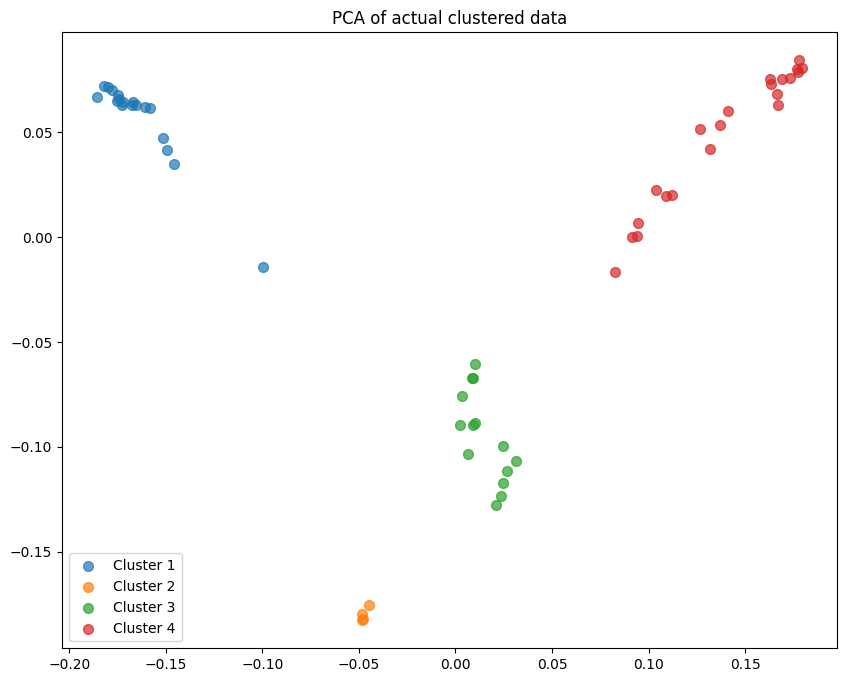

In [10]:
# Use the same data for both clustering and visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use your clustered data
pca = PCA(n_components=2)
low_dim = pca.fit_transform(weighted_data)  

plt.figure(figsize=(10, 8))
for cluster_id in range(1, n_clusters+1):
    mask = clusters == cluster_id
    plt.scatter(low_dim[mask, 0], low_dim[mask, 1], 
                label=f'Cluster {cluster_id}', alpha=0.7, s=50)
plt.legend()
plt.title('PCA of actual clustered data')
plt.show()

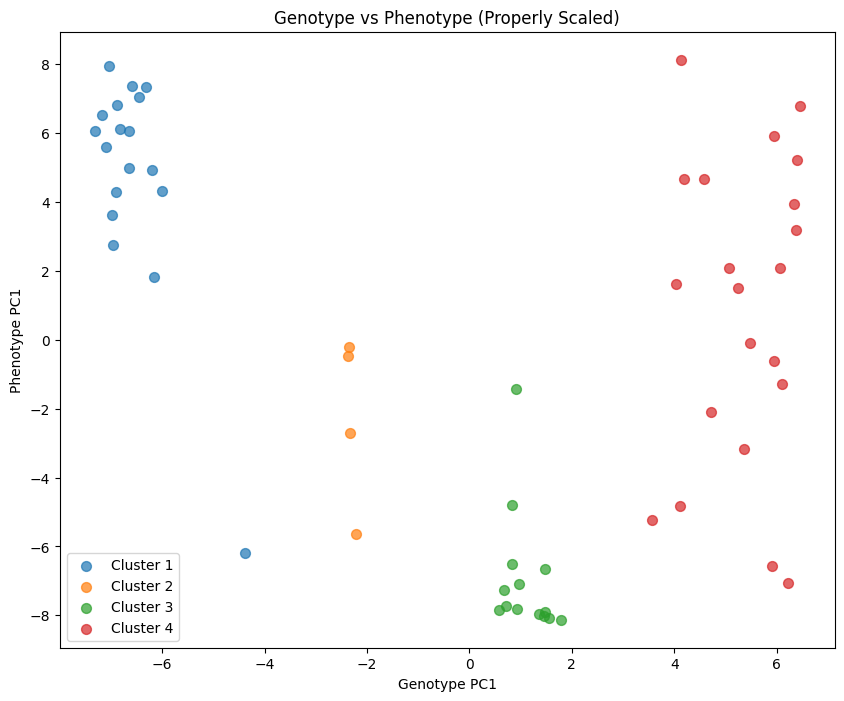

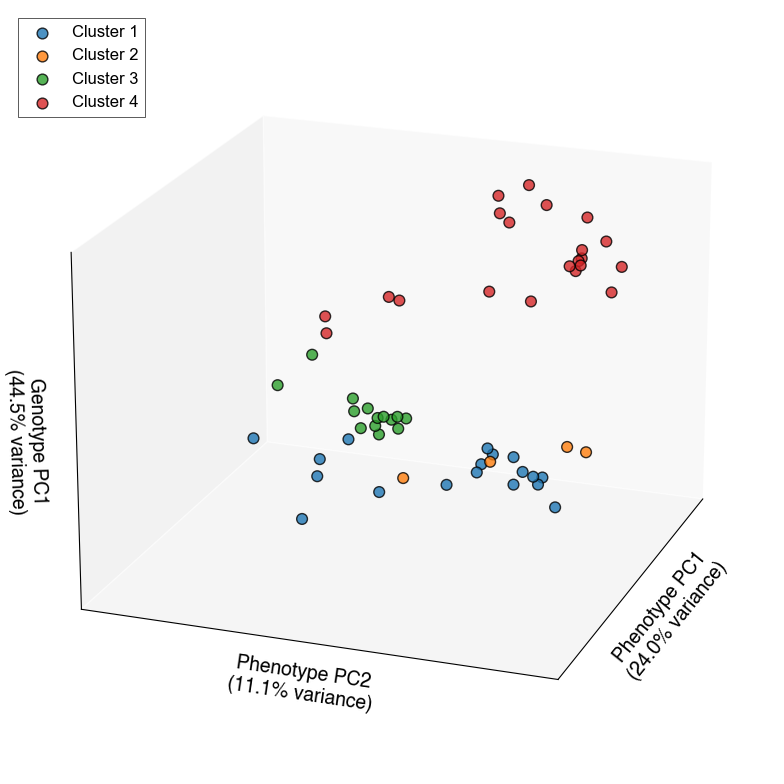

In [11]:
# Your original idea, but with proper scaling
from sklearn.preprocessing import StandardScaler

# Scale both genotype and phenotype data separately
scaler_g = StandardScaler()
scaler_p = StandardScaler()

phenotype_data = data[:, :130]  # Abundance data
genotype_data = data[:, 130:] 

genotype_scaled = scaler_g.fit_transform(genotype_data)
phenotype_scaled = scaler_p.fit_transform(phenotype_data)

# Use PCA to reduce each to 1D, focusing on maximum variance
pca_g_1d = PCA(n_components=1)
pca_p_1d = PCA(n_components=1)

genotype_1d = pca_g_1d.fit_transform(genotype_scaled)
phenotype_1d = pca_p_1d.fit_transform(phenotype_scaled)

plt.figure(figsize=(10, 8))
for cluster_id in range(1, n_clusters+1):
    mask = clusters == cluster_id
    plt.scatter(genotype_1d[mask], phenotype_1d[mask],
                label=f'Cluster {cluster_id}', alpha=0.7, s=50)
plt.xlabel('Genotype PC1')
plt.ylabel('Phenotype PC1')
plt.title('Genotype vs Phenotype (Properly Scaled)')
plt.legend()
plt.show()

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12
})

# Use PCA to reduce dimensions
pca_g = PCA(n_components=1)  # Just 1D for genotype
pca_p = PCA(n_components=2)  # 2D for phenotype

genotype_1d = pca_g.fit_transform(genotype_scaled)
phenotype_2d = pca_p.fit_transform(phenotype_scaled)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for cluster_id in range(1, n_clusters+1):
    mask = clusters == cluster_id
    color = colors[(cluster_id - 1) % len(colors)]
    ax.scatter(phenotype_2d[mask, 0], phenotype_2d[mask, 1], genotype_1d[mask, 0],
               label=f'Cluster {cluster_id}', alpha=0.8, s=60, color=color,
               edgecolor='black', linewidth=1)

ax.set_zlabel(f'Genotype PC1\n({pca_g.explained_variance_ratio_[0]:.1%} variance)', 
              fontname='Helvetica', fontsize=14, labelpad=0)
ax.set_xlabel(f'Phenotype PC1\n({pca_p.explained_variance_ratio_[0]:.1%} variance)', 
              fontname='Helvetica', fontsize=14, labelpad=0)
ax.set_ylabel(f'Phenotype PC2\n({pca_p.explained_variance_ratio_[1]:.1%} variance)', 
              fontname='Helvetica', fontsize=14, labelpad=0)

# Clean title with Helvetica
# ax.set_title('Genotype-Phenotype Relationship', 
#              fontname='Helvetica', fontsize=16, pad=-20)

legend = ax.legend(loc='upper left', bbox_to_anchor=(0, 1), 
                  frameon=True, fancybox=False, 
                  framealpha=0.9, edgecolor='black')
legend.get_frame().set_linewidth(0.5)
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# After creating your plot, try these specific views:
ax.view_init(elev=20, azim=200)   # Good overall view

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

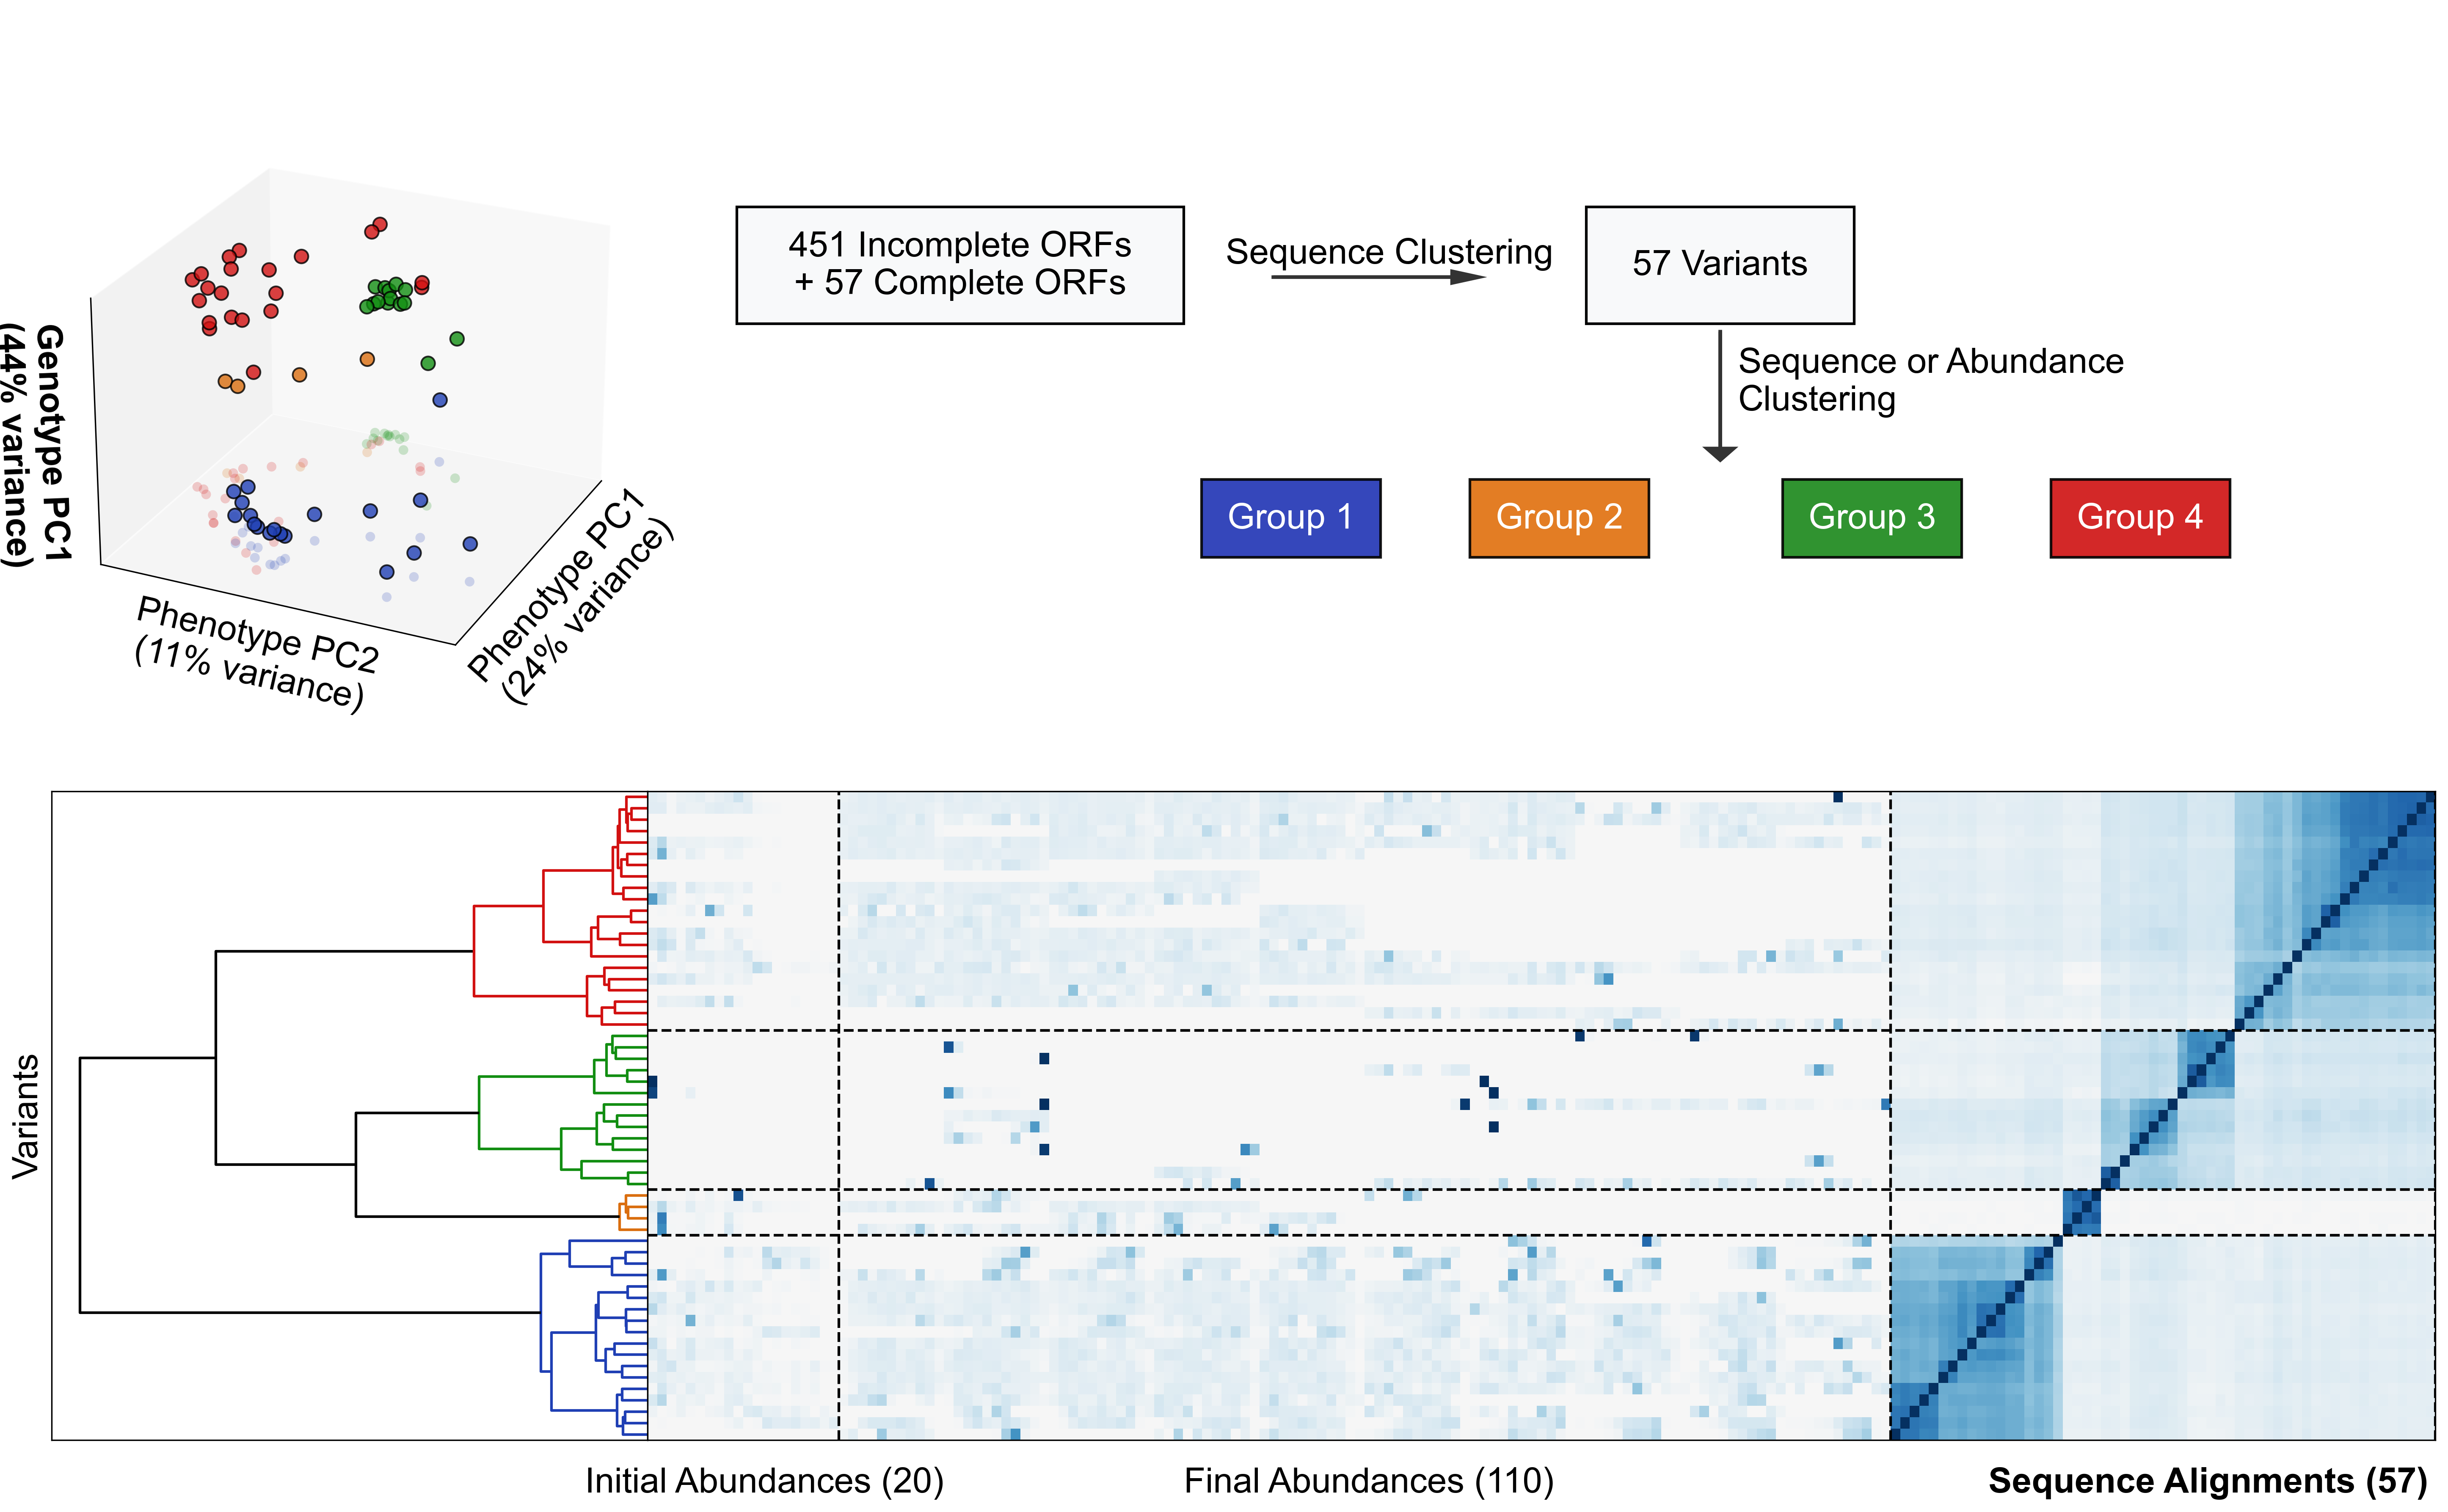

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex
import matplotlib.patches as patches


# Set Helvetica font
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
})

# Create a figure with the new layout
fig = plt.figure(figsize=(20, 12), dpi=300)

# Define a 2x2 grid layout with dendrogram taking much less space
# Reduced dendrogram width ratio significantly
gs = plt.GridSpec(2, 2, height_ratios=[1.2, 1], width_ratios=[0.5, 1.5], hspace=0, wspace=0)  # wspace=0 removes gap

# --- UPPER RIGHT: Horizontal Flow with Vertical Final Step ---
ax4 = fig.add_subplot(gs[0, 1])  # Upper right for flow diagram

# Remove axes and set bounds
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.axis('off')

# Define colors for the flow diagram
box_color = '#f8f9fa'
arrow_color = '#333333'
text_color = '#000000'

# Lower starting position to fill the space better
start_y = 6  

# Step 1: ORF Collection (Left)
ax4.add_patch(patches.Rectangle((0.5, start_y), 2.5, 1.5, facecolor=box_color, edgecolor='black', linewidth=1.5))
ax4.text(1.75, start_y + 0.75, '451 Incomplete ORFs\n+ 57 Complete ORFs', ha='center', va='center', 
         fontname='Arial', fontsize=20, color=text_color)

# Arrow 1 (Horizontal to Variants)
ax4.arrow(3.5, start_y + 0.6, 1, 0, head_width=0.15, head_length=0.15, fc=arrow_color, ec=arrow_color, linewidth=2)
ax4.text(4.15, start_y + 0.9, 'Sequence Clustering', ha='center', va='center', fontname='Arial', fontsize=20, 
         color=text_color)

# Step 2: Variants (Middle)
ax4.add_patch(patches.Rectangle((5.25, start_y), 1.5, 1.5, facecolor=box_color, edgecolor='black', linewidth=1.5))
ax4.text(6, start_y + 0.75, '57 Variants', ha='center', va='center', fontname='Arial', 
         fontsize=20, color=text_color)

# Arrow 2 (Vertical Downward to Groups)
ax4.arrow(6, start_y -0.1, 0, -1.5, head_width=0.15, head_length=0.15, fc=arrow_color, ec=arrow_color, linewidth=2)
ax4.text(6.1, start_y - 0.75, 'Sequence or Abundance\nClustering', ha='left', va='center', fontname='Arial', fontsize=20, 
         color=text_color)

# Step 3: Groups (Below Variants, arranged horizontally)
group_colors = ["#1f33b4", "#e06f0c", "#198719", "#cf1010"]
group_positions = [(3.6, start_y - 2.5), (5.1, start_y - 2.5), (6.85, start_y - 2.5), (8.35, start_y - 2.5)]

for i, (x, y) in enumerate(group_positions):
    ax4.add_patch(patches.Rectangle((x-0.5, y-0.5), 1, 1, 
                                   facecolor=group_colors[i], edgecolor='black', linewidth=1.5, alpha=0.9))
    ax4.text(x, y, f'Group {i+1}', ha='center', va='center', fontname='Arial', 
             fontsize=20, color='white')
# --- UPPER LEFT: 3D Plot ---
ax3 = fig.add_subplot(gs[0, 0], projection='3d')  # Upper left

# Prepare data for 3D plot
data_array = np.array(data)
phenotype_data = data_array[:, :130]
genotype_data = data_array[:, 130:]

scaler_g = StandardScaler()
scaler_p = StandardScaler()

genotype_scaled = scaler_g.fit_transform(genotype_data)
phenotype_scaled = scaler_p.fit_transform(phenotype_data)

pca_g = PCA(n_components=1)
pca_p = PCA(n_components=2)

genotype_1d = pca_g.fit_transform(genotype_scaled)
phenotype_2d = pca_p.fit_transform(phenotype_scaled)

# Define colors to match between plots
colors = ["#1f3fb4", "#da6e0f", "#128E12", "#d21111", '#9467bd', '#8c564b']


for cluster_id in range(1, n_clusters+1):
    mask = clusters == cluster_id
    color = colors[(cluster_id - 1) % len(colors)]
    ax3.scatter(phenotype_2d[mask, 0], phenotype_2d[mask, 1], genotype_1d[mask, 0],
               label=f'Cluster {cluster_id}', alpha=0.8, s=60, color=color,
               edgecolor='black', linewidth=1)
    
    ax3.scatter(phenotype_2d[mask, 0], phenotype_2d[mask, 1], 
            np.min(genotype_1d) - 0.1 * np.ptp(genotype_1d),  # Slightly below min Z
            alpha=0.2, s=30, color=color,
            edgecolor='none', zorder=0)  # zorder=0 puts them behind

ax3.set_zlabel(f'Genotype PC1\n({pca_g.explained_variance_ratio_[0]:.0%} variance)', 
              fontname='Arial', fontsize=20, labelpad=0, color = 'black', fontweight='bold')
ax3.set_xlabel(f'Phenotype PC1\n({pca_p.explained_variance_ratio_[0]:.0%} variance)', 
              fontname='Arial', fontsize=20, labelpad=0, color = 'black')
ax3.set_ylabel(f'Phenotype PC2\n({pca_p.explained_variance_ratio_[1]:.0%} variance)', 
              fontname='Arial', fontsize=20, labelpad=0, color = 'black')

# legend = ax3.legend(loc='upper left', bbox_to_anchor=(0, 1), 
#                   frameon=True, fancybox=False, 
#                   framealpha=0.9, edgecolor='black')
# legend.get_frame().set_linewidth(0.5)

ax3.xaxis.pane.set_edgecolor('white')
ax3.yaxis.pane.set_edgecolor('white')
ax3.zaxis.pane.set_edgecolor('white')
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_zticks([])
ax3.view_init(elev=25, azim=25) #originally 25 for both
ax3.set_facecolor('white')


# --- LOWER LEFT: Dendrogram (MUCH NARROWER) ---
ax1 = fig.add_subplot(gs[1, 0])  # Lower left - now much narrower

# Dendrogram code with matching colors
Z = linkage(weighted_data, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

n_clusters = 4
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}

next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1

# Use the same colors as 3D plot
cluster_colors = colors[:n_clusters]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Arial', fontsize=20)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

# Make dendrogram even tighter by adjusting margins
ax1.margins(x=0.01, y=0.01)

# --- LOWER RIGHT: Heatmap (NOW TAKES MOST OF THE SPACE, NO GAP) ---
ax2 = fig.add_subplot(gs[1, 1])  # Lower right - now much wider

rearranged_data = data_array[leaf_indices]
col_leaf_indices = leaf_indices + 130 * np.ones(len(leaf_indices), dtype=int)
rearranged_data[:, 130:187] = rearranged_data[:, col_leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin=-1, vmax=1)

# Dashed lines and boundaries
boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
for b in boundaries:
    ax2.axhline(b + 0.5, color='black', linestyle='--')
    
ax2.axvline(19.5, color='black', linestyle='--')
ax2.axvline(129.5, color='black', linestyle='--')
ax2.axvline(186.5, color='black', linestyle='--')

# No tick labels
ax2.set_xticks([])
ax2.set_yticks([])

# ax2.set_title('Clustering by Phenotype and Genotype', fontname='Helvetica', fontsize='x-large')

# X-axis label with text labels
# Simple colored x-axis labels
ax2.text(-0.035, -0.08, 'Initial Abundances (20)', color='black', 
         fontname='Arial', fontsize=20,
         transform=ax2.transAxes)
ax2.text(0.3, -0.08, 'Final Abundances (110)', color='black', 
         fontname='Arial', fontsize=20, 
         transform=ax2.transAxes)
ax2.text(0.75, -0.08, 'Sequence Alignments (57)', color='black', 
         fontname='Arial', fontsize=20, fontweight = 'bold',
         transform=ax2.transAxes)

# Remove the original xlabel since we're using custom text
ax2.set_xlabel('')

# Remove any margins from heatmap to ensure no gap
ax2.margins(x=0, y=0)

# Set overall figure background
fig.patch.set_facecolor('white')
# plt.savefig('../out/variants.pdf')

plt.tight_layout()
plt.show()

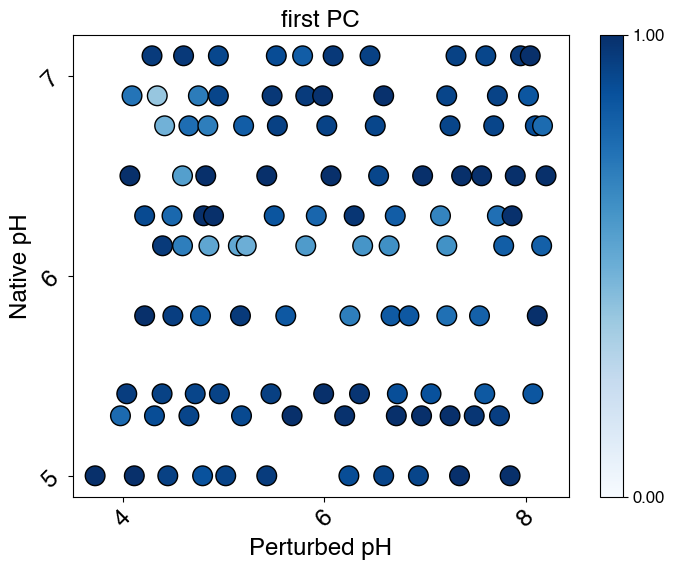

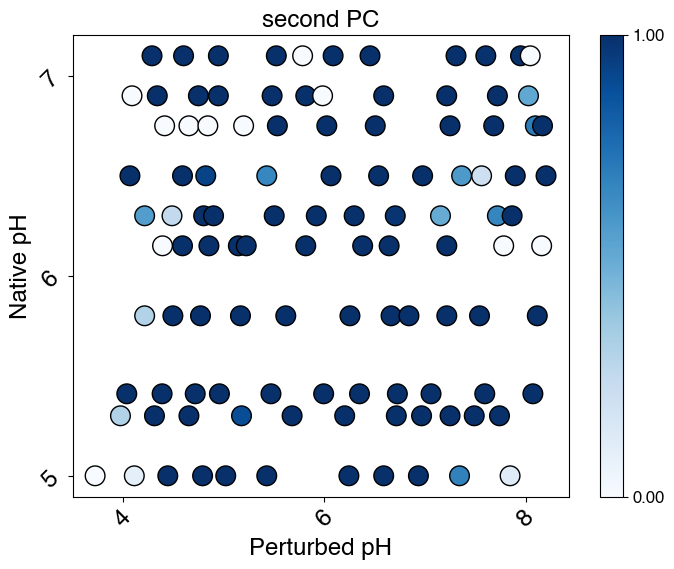

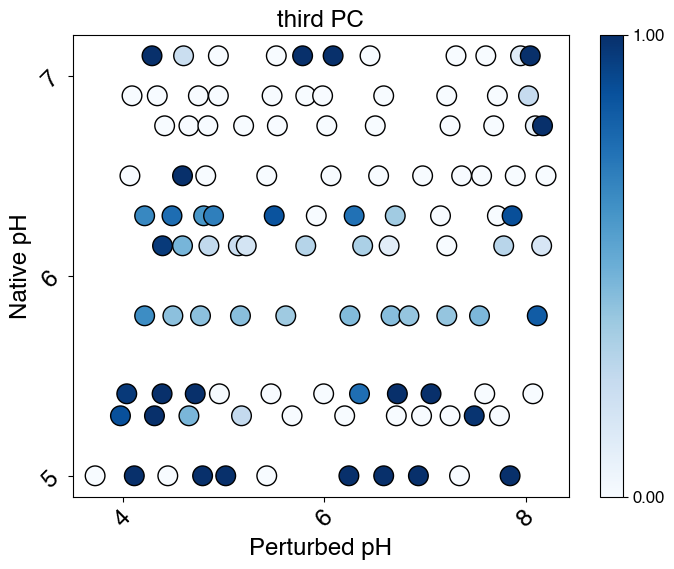

<Axes: title={'center': 'third PC'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [13]:
import numpy as np
from mgsa.helpers import plot
data_none = np.load('../out/sparse_regression/model1/pca_transformed_data_chl_neg.npy')
data_drug = np.load('../out/sparse_regression/model1/pca_transformed_data_chl_pos.npy')
plot((data_none[:,:,0] / data_drug[:,:,0]), 'first PC', vmin = 0, vmax = 1, cmap = 'Blues')
plot((data_none[:,:,1] / data_drug[:,:,1]), 'second PC', vmin = 0, vmax = 1, cmap = 'Blues')
plot((data_none[:,:,2] / data_drug[:,:,2]), 'third PC', vmin = 0, vmax = 1, cmap = 'Blues')

### Alignments and scatter plots in abundance and sequence space. 

[2. 1. 4. 1. 1. 1. 1. 4. 3. 4. 3. 1. 3. 4. 1. 1. 4. 3. 3. 1. 3. 1. 4. 4.
 4. 1. 1. 2. 1. 4. 3. 3. 4. 3. 4. 3. 3. 1. 4. 3. 4. 3. 4. 4. 1. 1. 4. 4.
 4. 3. 4. 4. 2. 1. 1. 2. 4.]


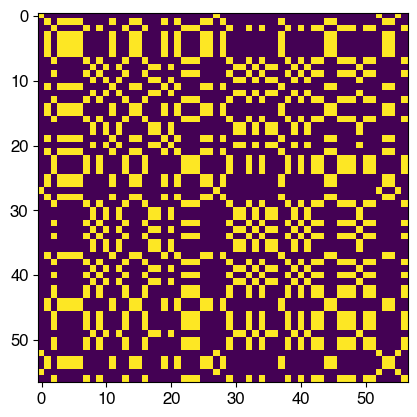

In [14]:
groups = pd.read_csv('../out/groups/assignments_K00370_v2.tsv', sep = '\t', header = None).values
group_id = np.zeros(57)
for i in range(57):
    group_id[i] = int(groups[i][0][-1])
print(group_id)
group_match = np.zeros((57, 57))
x = 0
for i in range(57):
    for j in range(57):
        if group_id[i] == group_id[j]:
            group_match[i, j] = 1
            x += 1
        
            
plt.imshow(group_match)

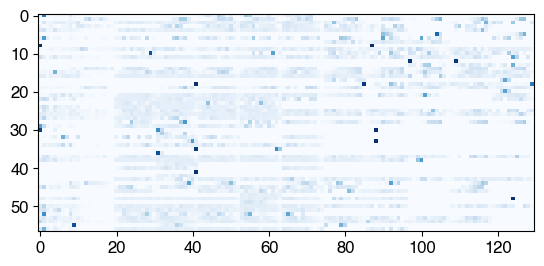

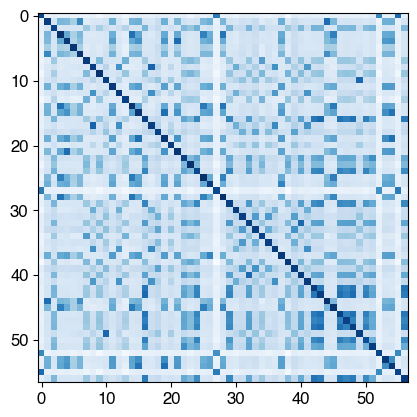

[[1.         0.23785098 0.35809229 ... 0.35997009 0.25731356 0.55778141]
 [0.18073477 1.         0.1833035  ... 0.28983657 0.12086334 0.18704297]
 [0.38464337 0.27166638 1.         ... 0.45821257 0.27974557 0.43778366]
 ...
 [0.42023435 0.40155274 0.48805084 ... 1.         0.32137023 0.56492313]
 [0.23888581 0.16186095 0.23002618 ... 0.23224082 1.         0.25736244]
 [0.58781662 0.29508551 0.45335844 ... 0.55232044 0.3245611  1.        ]]


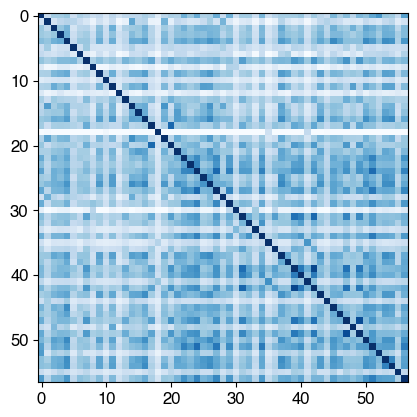

Text(0, 0.5, 'Sequence Alignment Score')

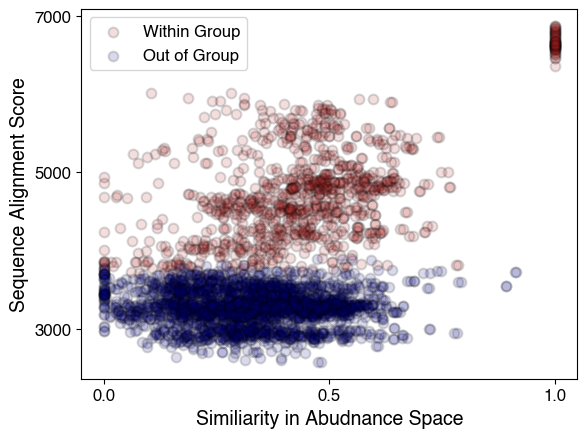

In [15]:
from scipy.spatial.distance import cdist

plt.imshow(data_abundances, cmap = 'Blues')
plt.show()
plt.imshow(data_sequences, cmap = 'Blues')
plt.show()

scaler = MinMaxScaler()
data_abundances_pairwise = cdist(data_abundances, data_abundances, metric = 'euclidean')
data_abundances_pairwise = scaler.fit_transform(data_abundances_pairwise)
data_abundances_pairwise = 1 - data_abundances_pairwise
plt.imshow(data_abundances_pairwise, cmap = 'Blues')
print(data_abundances_pairwise)
plt.show()


group_match_flat = group_match.flatten()
mask_one = group_match_flat == 1
mask_zero = group_match_flat == 0

data_abundances_flat = data_abundances_pairwise.flatten()
data_sequences_flat = data_sequences.flatten()
plt.scatter(data_abundances_flat[mask_one], data_sequences_flat[mask_one],   color = 'firebrick', edgecolors='Black', alpha = 0.15, s=50, linewidth=1.5, label = 'Within Group')
plt.scatter(data_abundances_flat[mask_zero], data_sequences_flat[mask_zero], color = 'navy', edgecolors='Black', alpha = 0.15, s=50, linewidth=1.5, label = 'Out of Group')
plt.legend()
plt.xticks([0, 0.5, 1])
plt.yticks([3000, 5000, 7000])
plt.xlabel('Similiarity in Abudnance Space')
plt.ylabel('Sequence Alignment Score')

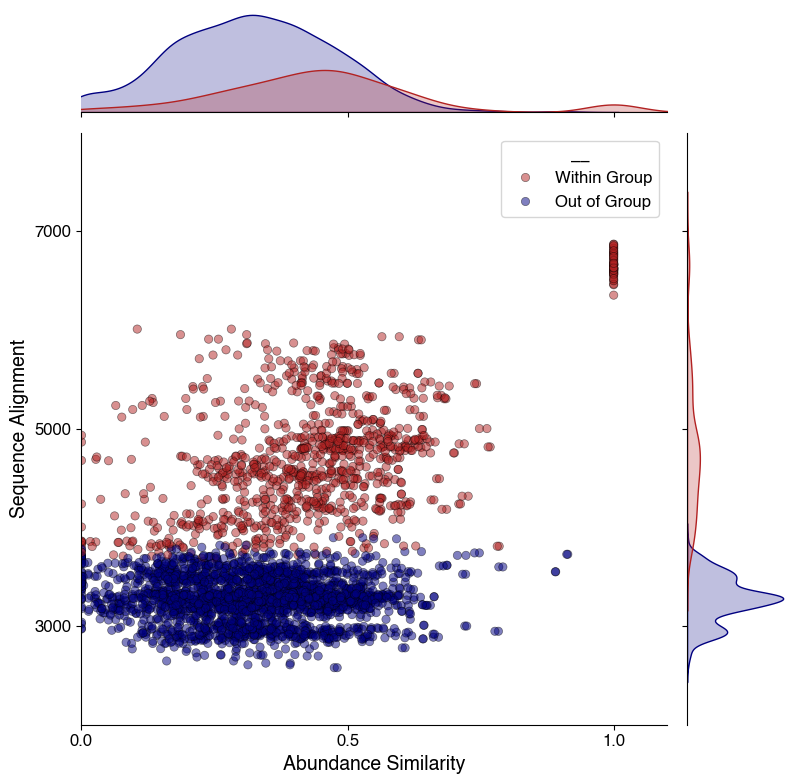

In [16]:
import seaborn as sns
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    'Abundance Similarity': data_abundances_flat,
    'Sequence Alignment': data_sequences_flat,
    '__': ['Within Group' if m else 'Out of Group' for m in mask_one]
})

# Create joint plot
g = sns.jointplot(data=df, x='Abundance Similarity', y='Sequence Alignment', 
                  hue='__', palette={'Within Group': 'firebrick', 'Out of Group': 'navy'},
                  alpha=0.5, edgecolor='black', height=8)

# Set ticks
g.ax_joint.set_xticks([0, 0.5, 1])
g.ax_joint.set_yticks([3000, 5000, 7000])

# Set limits - ADD THESE LINES
g.ax_joint.set_xlim([0, 1.1])  # Set x-axis limits from 0 to 1
g.ax_joint.set_ylim([2000, 8000])  # Set y-axis limits (adjust as needed)
# Or if you want tighter limits based on your ticks:
# g.ax_joint.set_ylim([2500, 7500])

# Also update the marginal plots to match
g.ax_marg_x.set_xlim([0, 1.1])  # For the top histogram
g.ax_marg_y.set_ylim([2000, 8000])  # For the right histogram

plt.show()

### Make the alpha vs grouping plot

Need to fill in a 57 row 100 or so column matrix for variant group membership versus alpha. 

In [17]:
membership_matrix = np.zeros((57, 100))

alpha_sweep = np.linspace(0,1,100)

strc_data = pd.read_csv(f'../out/structure_analysis/{KO}/structure_metrics_{KO}.tsv', sep='\t').values
strc_data = strc_data[:, 1:]#remove the first column (orf names)
orf_list = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header=None).values
pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')

scaler = MinMaxScaler()
strc_data = scaler.fit_transform(strc_data)

for j, a in enumerate(alpha_sweep):
    np.random.seed(42)


    data_abs = T0data
    T0data = T0data / T0data.sum(axis = 1, keepdims=True)
    T0data = np.nan_to_num(T0data, nan = 0)

    data = T0data 
    for i in range(10):
        T9temp = T9data[:,i,:]
        data_abs = np.hstack((data_abs, T9temp))
        T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)
        T9temp = np.nan_to_num(T9temp, nan = 0)
        data = np.hstack((data, T9temp))
        


    data_abundances = data #saving for later
    data_sequences = pairwise_data #saving for later

    pairwise_data = scaler.fit_transform(pairwise_data)


    data = np.hstack((data, pairwise_data))
    data_abs = np.hstack((data_abs, pairwise_data))

    weights = np.concatenate([
        np.full(20, a**2/np.sqrt(130)),    
        np.full(110, a**2/np.sqrt(130)) ,
        np.full(57, (np.sqrt(1 - a**2))/np.sqrt(57))
    ])


    weighted_data = data * weights 
    


    Z = linkage(weighted_data, method='ward', metric='euclidean')
    Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

    n_clusters = 4
    clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')
    membership_matrix[:, j] = clusters

    


In [18]:
membership_matrix = np.zeros((57, 100))

alpha_sweep = np.linspace(0,1,100)

strc_data = pd.read_csv(f'../out/structure_analysis/{KO}/structure_metrics_{KO}.tsv', sep='\t').values
strc_data = strc_data[:, 1:]#remove the first column (orf names)
orf_list = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header=None).values
pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')

scaler = MinMaxScaler()
strc_data = scaler.fit_transform(strc_data)


reference_clusters = None

for j, a in enumerate(alpha_sweep):
    np.random.seed(42)

    data_abs = T0data
    T0data = T0data / T0data.sum(axis = 1, keepdims=True)
    T0data = np.nan_to_num(T0data, nan = 0)

    data = T0data 
    for i in range(10):
        T9temp = T9data[:,i,:]
        data_abs = np.hstack((data_abs, T9temp))
        T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)
        T9temp = np.nan_to_num(T9temp, nan = 0)
        data = np.hstack((data, T9temp))

    data_abundances = data #saving for later
    data_sequences = pairwise_data #saving for later

    pairwise_data = scaler.fit_transform(pairwise_data)

    data = np.hstack((data, pairwise_data))
    data_abs = np.hstack((data_abs, pairwise_data))

    weights = np.concatenate([
        np.full(20, a**2/np.sqrt(130)),    
        np.full(110, a**2/np.sqrt(130)) ,
        np.full(57, (np.sqrt(1 - a**2))/np.sqrt(57))
    ])

    weighted_data = data * weights 

    Z = linkage(weighted_data, method='ward', metric='euclidean')
    Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

    n_clusters = 4
    clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')
    
    #do some relabeling: based on a reference, change labels to best match the reference, without changing the actually group categorization.
    if j == 0:
        #store a reference
        reference_clusters = clusters.copy()
        membership_matrix[:, j] = clusters
    else:
        #relabel to match reference
        from scipy.optimize import linear_sum_assignment
        
        confusion = np.zeros((n_clusters, n_clusters))
        for k in range(1, n_clusters+1):
            for l in range(1, n_clusters+1):
                confusion[k-1, l-1] = np.sum((reference_clusters == k) & (clusters == l))
        
        row_ind, col_ind = linear_sum_assignment(-confusion)  
        
        mapping = {}
        for ref_idx, curr_idx in zip(row_ind, col_ind):
            mapping[curr_idx + 1] = ref_idx + 1

        relabeled_clusters = np.array([mapping[x] for x in clusters])
        membership_matrix[:, j] = relabeled_clusters

Text(0.5, 1.02, '(for varied weighting in assignment mechanism)')

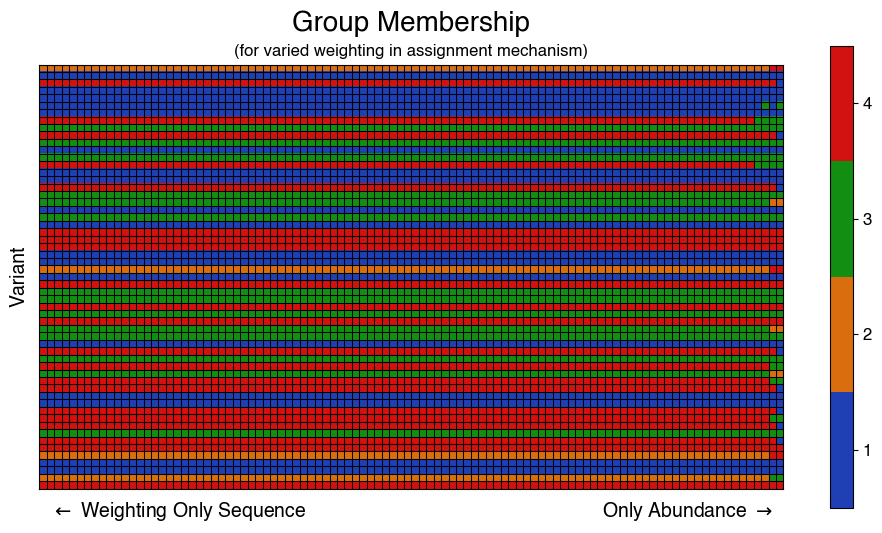

In [20]:
from matplotlib.colors import ListedColormap
colors = ["#1f3fb4", "#da6e0f", "#128E12", "#d21111"]
cmap = ListedColormap(colors)
plt.figure(figsize=(12, 6))
im = plt.imshow(membership_matrix, cmap = cmap, vmin = 0.5, vmax = 4.5)


plt.grid(True, color='black', linewidth=0.75)
plt.gca().set_xticks(np.arange(-0.5, membership_matrix.shape[1], 1))
plt.gca().set_yticks(np.arange(-0.5, membership_matrix.shape[0], 1))
plt.gca().tick_params(axis='both', which='both', length=0)
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])

cbar = plt.colorbar(im, ticks=[1, 2, 3, 4])
cbar.set_ticklabels(['1', '2', '3', '4'])

x_tick_positions = np.linspace(0, membership_matrix.shape[1] - 1, 4).astype(int)
x_tick_labels = np.linspace(0, 1, 4).round(2)  # 0, 0.33, 0.67, 1 or similar

y_tick_positions = np.linspace(0, membership_matrix.shape[0] - 1, 3).astype(int)
y_tick_labels = np.linspace(1, 57, 3).astype(int)


plt.xlabel(r"$\leftarrow$ Weighting Only Sequence                                                       Only Abundance $\rightarrow$")
plt.ylabel("Variant")
plt.text(0.5, 1.08, 'Group Membership', 
         transform=plt.gca().transAxes, 
         ha='center', 
         fontsize=20, 
         style='italic')
plt.text(0.5, 1.02, '(for varied weighting in assignment mechanism)', 
         transform=plt.gca().transAxes, 
         ha='center', 
         fontsize=12, 
         style='italic')
